# AirPanel Metric Formalization

## From random-forest motivation to a technical evaluation layer

This notebook transforms the current AirPanel outputs into a research-oriented analysis artifact. It uses the existing `airpanel_metric_formalization.py` outputs as a measurement contract, investigates the empirical structure of the scores, and exports paper-ready tables and figures.

The random-forest result is treated as motivation: it shows that a small set of response dimensions can reconstruct preference. The contribution explored here is more technical: a formal representation of advertising response through construct differences, composite metrics, divergence metrics, question-level signal strength, and preference-reconstruction baselines.


## What the Python script creates

The script `airpanel_metric_formalization.py` reads the respondent score files and creates a compact metric layer:

- `metric_catalog.csv/json`: definitions of the metric families, formulas, inputs, outputs, interpretation, and caveats.
- `respondent_construct_metrics.csv`: one row per panelist with raw scores plus derived construct differences, creative/commercial composites, divergence metrics, and preference labels.
- `construct_distribution_summary.csv`: descriptive statistics for each brand-difference metric.
- `construct_validity_summary.csv`: correlations between construct differences and the overall preference difference.
- `preference_model_summary.csv`: cross-validated baselines that reconstruct the overall preference label from construct features.
- `question_signal_table.csv`: one row per question and dimension, ranking which interview questions carry the strongest signal.
- `run_summary.json`: data provenance and output contract summary.

Important: this is not yet a claim that the model predicts real human market behavior. It is an internal coherence and representation analysis of the current AirPanel scoring pipeline.


In [1]:
from pathlib import Path
import json
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_DIR = Path("/Users/martateodoratrales/Documents/New project")
SCRIPT_PATH = PROJECT_DIR / "airpanel_metric_formalization.py"
OUTPUT_DIR = PROJECT_DIR / "airpanel_metric_outputs"
FIG_DIR = OUTPUT_DIR / "paper_figures"
TABLE_DIR = OUTPUT_DIR / "paper_tables"
RF_OUTPUT_DIR = Path("/Users/martateodoratrales/Desktop/AirPanel/rf_outputs")

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

required_outputs = [
    "metric_catalog.csv",
    "respondent_construct_metrics.csv",
    "construct_distribution_summary.csv",
    "construct_validity_summary.csv",
    "preference_model_summary.csv",
    "question_signal_table.csv",
    "run_summary.json",
]

missing = [name for name in required_outputs if not (OUTPUT_DIR / name).exists()]
if missing:
    print("Missing metric outputs:", missing)
    print("Running airpanel_metric_formalization.py first...")
    subprocess.run([sys.executable, str(SCRIPT_PATH)], cwd=PROJECT_DIR, check=True)

print("Project:", PROJECT_DIR)
print("Metric outputs:", OUTPUT_DIR)
print("Paper figures:", FIG_DIR)
print("Paper tables:", TABLE_DIR)


Project: /Users/martateodoratrales/Documents/New project
Metric outputs: /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs
Paper figures: /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures
Paper tables: /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables


In [2]:
catalog = pd.read_csv(OUTPUT_DIR / "metric_catalog.csv")
metrics = pd.read_csv(OUTPUT_DIR / "respondent_construct_metrics.csv")
distribution = pd.read_csv(OUTPUT_DIR / "construct_distribution_summary.csv")
validity = pd.read_csv(OUTPUT_DIR / "construct_validity_summary.csv")
model_summary = pd.read_csv(OUTPUT_DIR / "preference_model_summary.csv")
qsignals = pd.read_csv(OUTPUT_DIR / "question_signal_table.csv")
run_summary = json.loads((OUTPUT_DIR / "run_summary.json").read_text())

print("Panelists:", run_summary["n_panelists"])
print("Resolved preferences:", run_summary["n_resolved_preferences"])
print("Metric catalog rows:", len(catalog))
print("Respondent metric table:", metrics.shape)
print("Question signal table:", qsignals.shape)

display(pd.DataFrame(
    {
        "artifact": run_summary["output_files"],
        "path": [str(OUTPUT_DIR / name) for name in run_summary["output_files"]],
    }
))


Panelists: 800
Resolved preferences: 763
Metric catalog rows: 7
Respondent metric table: (800, 107)
Question signal table: (132, 10)


,artifact,path
0,construct_distribution_summary.csv,/Users/martateodoratrales/Documents/New projec...
1,construct_validity_summary.csv,/Users/martateodoratrales/Documents/New projec...
2,metric_catalog.csv,/Users/martateodoratrales/Documents/New projec...
3,metric_catalog.json,/Users/martateodoratrales/Documents/New projec...
4,preference_model_summary.csv,/Users/martateodoratrales/Documents/New projec...
5,question_signal_table.csv,/Users/martateodoratrales/Documents/New projec...
6,respondent_construct_metrics.csv,/Users/martateodoratrales/Documents/New projec...
7,run_summary.json,/Users/martateodoratrales/Documents/New projec...


In [3]:
LABELS = {
    "creativity_diff": "Creativity",
    "humour_diff": "Humour",
    "originality_diff": "Originality",
    "reliability_trust_diff": "Reliability/trust",
    "intent_to_purchase_diff": "Intent to purchase",
    "informativeness_diff": "Informativeness",
    "expressivity_diff": "Expressivity",
    "overall_diff": "Overall preference",
    "creative_salience_core_diff": "Creative salience, core",
    "commercial_persuasion_core_diff": "Commercial persuasion, core",
    "creative_commercial_divergence_core_diff": "Creative-commercial divergence, core",
    "creative_salience_extended_diff": "Creative salience, extended",
    "commercial_persuasion_extended_diff": "Commercial persuasion, extended",
    "creative_commercial_divergence_extended_diff": "Creative-commercial divergence, extended",
}

FEATURE_SET_LABELS = {
    "axis_diffs_core_5": "Five core axes",
    "top2_commercial_axis_diffs": "Two commercial axes",
    "creative_axes_only": "Creative axes only",
    "construct_composites_core": "Core composites",
    "axis_diffs_extended_7": "Seven axes",
    "construct_composites_extended": "Extended composites",
}


def nice_metric(name):
    return LABELS.get(name, name.replace("_diff", "").replace("_", " ").title())


def export_table(df, stem, latex=True):
    csv_path = TABLE_DIR / f"{stem}.csv"
    df.to_csv(csv_path, index=False)
    print(f"saved {csv_path}")
    if latex:
        tex_path = TABLE_DIR / f"{stem}.tex"
        tex_path.write_text(df.to_latex(index=False, escape=True), encoding="utf-8")
        print(f"saved {tex_path}")


## Data contract and formula audit

Before interpreting figures, the notebook verifies that the generated files are internally consistent. This matters academically because the contribution depends on the metric layer being explicit and auditable, not just visually persuasive.


In [4]:
expected_files = {
    "metric_catalog.csv": "metric definitions and caveats",
    "respondent_construct_metrics.csv": "respondent-level construct table",
    "construct_distribution_summary.csv": "descriptive metric summary",
    "construct_validity_summary.csv": "construct-overall convergence",
    "preference_model_summary.csv": "preference reconstruction baselines",
    "question_signal_table.csv": "question-by-dimension signal ranking",
    "run_summary.json": "provenance and run summary",
}

for filename in expected_files:
    assert (OUTPUT_DIR / filename).exists(), f"Missing expected output file: {filename}"

assert metrics["panelist_id"].is_unique, "panelist_id should be unique at respondent level"
assert run_summary["n_panelists"] == metrics["panelist_id"].nunique(), "panelist count mismatch"
assert run_summary["n_resolved_preferences"] == int(metrics["pref_bouygues_binary"].notna().sum()), "resolved preference count mismatch"

required_cols = [
    "panelist_id",
    "overall_bouygues",
    "overall_orange",
    "overall_diff",
    "resolved_preference",
    "pref_bouygues_binary",
    "creativity_bouygues",
    "creativity_orange",
    "humour_bouygues",
    "humour_orange",
    "originality_bouygues",
    "originality_orange",
    "reliability_trust_bouygues",
    "reliability_trust_orange",
    "intent_to_purchase_bouygues",
    "intent_to_purchase_orange",
    "creative_salience_core_diff",
    "commercial_persuasion_core_diff",
    "creative_commercial_divergence_core_diff",
]
missing_cols = [col for col in required_cols if col not in metrics.columns]
assert not missing_cols, f"Missing required columns: {missing_cols}"

contract_rows = []
objects = {
    "metric_catalog.csv": catalog,
    "respondent_construct_metrics.csv": metrics,
    "construct_distribution_summary.csv": distribution,
    "construct_validity_summary.csv": validity,
    "preference_model_summary.csv": model_summary,
    "question_signal_table.csv": qsignals,
}
for filename, obj in objects.items():
    contract_rows.append(
        {
            "artifact": filename,
            "role": expected_files[filename],
            "rows": obj.shape[0],
            "columns": obj.shape[1],
            "path": str(OUTPUT_DIR / filename),
        }
    )
data_contract = pd.DataFrame(contract_rows)
export_table(data_contract, "paper_table_data_contract", latex=False)
display(data_contract)


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_data_contract.csv


,artifact,role,rows,columns,path
0,metric_catalog.csv,metric definitions and caveats,7,8,/Users/martateodoratrales/Documents/New projec...
1,respondent_construct_metrics.csv,respondent-level construct table,800,107,/Users/martateodoratrales/Documents/New projec...
2,construct_distribution_summary.csv,descriptive metric summary,14,8,/Users/martateodoratrales/Documents/New projec...
3,construct_validity_summary.csv,construct-overall convergence,13,6,/Users/martateodoratrales/Documents/New projec...
4,preference_model_summary.csv,preference reconstruction baselines,12,9,/Users/martateodoratrales/Documents/New projec...
5,question_signal_table.csv,question-by-dimension signal ranking,132,10,/Users/martateodoratrales/Documents/New projec...


In [5]:
def assert_close(name, observed, expected, tolerance=1e-9):
    err = (observed - expected).abs().max()
    assert err < tolerance, f"{name} formula mismatch; max error={err}"
    return {"formula": name, "max_abs_error": float(err), "status": "pass"}


formula_checks = []

for axis in [
    "creativity",
    "humour",
    "originality",
    "reliability_trust",
    "intent_to_purchase",
    "informativeness",
    "expressivity",
]:
    b_col = f"{axis}_bouygues"
    o_col = f"{axis}_orange"
    d_col = f"{axis}_diff"
    if {b_col, o_col, d_col}.issubset(metrics.columns):
        formula_checks.append(assert_close(d_col, metrics[d_col], metrics[b_col] - metrics[o_col]))

composite_specs = {
    "creative_salience_core": ["creativity", "humour", "originality"],
    "commercial_persuasion_core": ["reliability_trust", "intent_to_purchase"],
    "creative_salience_extended": ["creativity", "humour", "originality", "expressivity"],
    "commercial_persuasion_extended": ["reliability_trust", "intent_to_purchase", "informativeness"],
}

for prefix, axes in composite_specs.items():
    for brand in ["bouygues", "orange"]:
        cols = [f"{axis}_{brand}" for axis in axes if f"{axis}_{brand}" in metrics.columns]
        out_col = f"{prefix}_{brand}"
        if cols and out_col in metrics.columns:
            formula_checks.append(assert_close(out_col, metrics[out_col], metrics[cols].mean(axis=1)))
    d_col = f"{prefix}_diff"
    b_col = f"{prefix}_bouygues"
    o_col = f"{prefix}_orange"
    if {d_col, b_col, o_col}.issubset(metrics.columns):
        formula_checks.append(assert_close(d_col, metrics[d_col], metrics[b_col] - metrics[o_col]))

for suffix in ["core", "extended"]:
    for brand in ["bouygues", "orange"]:
        div_col = f"creative_commercial_divergence_{suffix}_{brand}"
        creative_col = f"creative_salience_{suffix}_{brand}"
        commercial_col = f"commercial_persuasion_{suffix}_{brand}"
        if {div_col, creative_col, commercial_col}.issubset(metrics.columns):
            formula_checks.append(
                assert_close(div_col, metrics[div_col], metrics[creative_col] - metrics[commercial_col])
            )
    d_col = f"creative_commercial_divergence_{suffix}_diff"
    b_col = f"creative_commercial_divergence_{suffix}_bouygues"
    o_col = f"creative_commercial_divergence_{suffix}_orange"
    if {d_col, b_col, o_col}.issubset(metrics.columns):
        formula_checks.append(assert_close(d_col, metrics[d_col], metrics[b_col] - metrics[o_col]))

formula_checks.append(assert_close("overall_diff", metrics["overall_diff"], metrics["overall_bouygues"] - metrics["overall_orange"]))

resolved_expected = np.select(
    [metrics["overall_diff"] > 0, metrics["overall_diff"] < 0],
    ["bouygues", "orange"],
    default="tie",
)
assert (metrics["resolved_preference"].astype(str).values == resolved_expected).all(), "resolved_preference formula mismatch"
binary_expected = pd.Series(np.where(metrics["overall_diff"] > 0, 1.0, 0.0), index=metrics.index)
binary_expected.loc[metrics["overall_diff"] == 0] = np.nan
assert metrics["pref_bouygues_binary"].fillna(-1).eq(binary_expected.fillna(-1)).all(), "binary preference formula mismatch"
formula_checks.append({"formula": "resolved_preference and pref_bouygues_binary", "max_abs_error": 0.0, "status": "pass"})

formula_audit = pd.DataFrame(formula_checks)
export_table(formula_audit, "paper_table_formula_audit", latex=False)
display(formula_audit)


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_formula_audit.csv


,formula,max_abs_error,status
0,creativity_diff,0.000000e+00,pass
1,humour_diff,0.000000e+00,pass
2,originality_diff,0.000000e+00,pass
3,reliability_trust_diff,0.000000e+00,pass
4,intent_to_purchase_diff,0.000000e+00,pass
5,informativeness_diff,0.000000e+00,pass
6,expressivity_diff,0.000000e+00,pass
7,creative_salience_core_bouygues,0.000000e+00,pass
8,creative_salience_core_orange,0.000000e+00,pass
9,creative_salience_core_diff,5.551115e-17,pass


## Mathematical object of study

For panelist `i`, construct axis `a`, and brands `B = Bouygues`, `O = Orange`, the base representation is the signed brand difference:

`d_{i,a} = s_{i,a,B} - s_{i,a,O}`.

Positive values mean Bouygues receives the higher score on that axis. Negative values mean Orange receives the higher score.

The first composite layer is:

`creative_salience_i = mean(creativity_i, humour_i, originality_i[, expressivity_i])`

`commercial_persuasion_i = mean(reliability_trust_i, intent_to_purchase_i[, informativeness_i])`

The divergence layer is:

`creative_commercial_divergence_i = creative_salience_i - commercial_persuasion_i`.

The learning question is then whether low-dimensional construct representations preserve the preference structure:

`P(preference_i = Bouygues | construct differences_i)`.

This is a representation and evaluation problem, not only a classifier problem.


## Target and simple baselines

The target is generated from the overall score difference. Ties are excluded from binary preference modeling. These simple baselines keep the later random-forest and logistic-regression results anchored.


In [6]:
target_df = metrics.dropna(subset=["pref_bouygues_binary"]).copy()
y = target_df["pref_bouygues_binary"].astype(int)
target_counts = metrics["resolved_preference"].value_counts().rename_axis("preference").reset_index(name="n")
target_counts["pct"] = 100 * target_counts["n"] / len(metrics)
export_table(target_counts, "paper_table_preference_balance", latex=False)
display(target_counts)

baseline_rows = []
majority_class = int(y.mode().iloc[0])
majority_pred = np.full(len(y), majority_class)
baseline_rows.append(
    {
        "baseline": f"majority class ({'Bouygues' if majority_class == 1 else 'Orange'})",
        "feature": "none",
        "accuracy": accuracy_score(y, majority_pred),
        "balanced_accuracy": balanced_accuracy_score(y, majority_pred),
        "f1_bouygues": f1_score(y, majority_pred, zero_division=0),
        "roc_auc": np.nan,
    }
)

single_feature_candidates = [
    "creative_salience_core_diff",
    "commercial_persuasion_core_diff",
    "intent_to_purchase_diff",
    "reliability_trust_diff",
    "creative_commercial_divergence_core_diff",
]
for feature in single_feature_candidates:
    if feature not in target_df.columns:
        continue
    tmp = target_df[[feature, "pref_bouygues_binary"]].dropna()
    yy = tmp["pref_bouygues_binary"].astype(int)
    pred = (tmp[feature] > 0).astype(int)
    score = tmp[feature]
    if yy.nunique() == 2:
        auc = roc_auc_score(yy, score)
    else:
        auc = np.nan
    baseline_rows.append(
        {
            "baseline": "single-feature sign threshold",
            "feature": nice_metric(feature),
            "accuracy": accuracy_score(yy, pred),
            "balanced_accuracy": balanced_accuracy_score(yy, pred),
            "f1_bouygues": f1_score(yy, pred, zero_division=0),
            "roc_auc": auc,
        }
    )

baseline_table = pd.DataFrame(baseline_rows).round(3)
export_table(baseline_table, "paper_table_simple_baselines")
display(baseline_table)


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_preference_balance.csv


,preference,n,pct
0,orange,594,74.250
1,bouygues,169,21.125
2,tie,37,4.625


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_simple_baselines.csv
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_simple_baselines.tex


,baseline,feature,accuracy,balanced_accuracy,f1_bouygues,roc_auc
0,majority class (Orange),none,0.779,0.500,0.000,NaN
1,single-feature sign threshold,"Creative salience, core",0.275,0.535,0.379,0.955
2,single-feature sign threshold,"Commercial persuasion, core",0.858,0.680,0.530,0.996
3,single-feature sign threshold,Intent to purchase,0.896,0.766,0.695,0.982
4,single-feature sign threshold,Reliability/trust,0.803,0.556,0.202,0.962
5,single-feature sign threshold,"Creative-commercial divergence, core",0.220,0.497,0.361,0.191


In [7]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 320,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "font.family": "DejaVu Sans",
    }
)

BOUYGUES_COLOR = "#2a9d8f"
ORANGE_COLOR = "#e76f51"
TIE_COLOR = "#7a869a"
NEUTRAL = "#4b5563"

LABELS = {
    "creativity_diff": "Creativity",
    "humour_diff": "Humour",
    "originality_diff": "Originality",
    "reliability_trust_diff": "Reliability/trust",
    "intent_to_purchase_diff": "Intent to purchase",
    "informativeness_diff": "Informativeness",
    "expressivity_diff": "Expressivity",
    "overall_diff": "Overall preference",
    "creative_salience_core_diff": "Creative salience, core",
    "commercial_persuasion_core_diff": "Commercial persuasion, core",
    "creative_commercial_divergence_core_diff": "Creative-commercial divergence, core",
    "creative_salience_extended_diff": "Creative salience, extended",
    "commercial_persuasion_extended_diff": "Commercial persuasion, extended",
    "creative_commercial_divergence_extended_diff": "Creative-commercial divergence, extended",
}

FEATURE_SET_LABELS = {
    "axis_diffs_core_5": "Five core axes",
    "top2_commercial_axis_diffs": "Two commercial axes",
    "creative_axes_only": "Creative axes only",
    "construct_composites_core": "Core composites",
    "axis_diffs_extended_7": "Seven axes",
    "construct_composites_extended": "Extended composites",
}


def nice_metric(name):
    return LABELS.get(name, name.replace("_diff", "").replace("_", " ").title())


def save_figure(fig, stem):
    png_path = FIG_DIR / f"{stem}.png"
    pdf_path = FIG_DIR / f"{stem}.pdf"
    fig.savefig(png_path, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    print(f"saved {png_path}")
    print(f"saved {pdf_path}")


def export_table(df, stem, latex=True):
    csv_path = TABLE_DIR / f"{stem}.csv"
    df.to_csv(csv_path, index=False)
    print(f"saved {csv_path}")
    if latex:
        tex_path = TABLE_DIR / f"{stem}.tex"
        tex_path.write_text(df.to_latex(index=False, escape=True), encoding="utf-8")
        print(f"saved {tex_path}")


## Metric catalog

This is the paper-facing dictionary of the measurement layer. It is useful because it makes the assumptions explicit: what is measured, how it is computed, what interpretation is allowed, and what caveat must travel with the metric.


In [8]:
catalog_view = catalog[
    [
        "metric_id",
        "family",
        "formula",
        "input_level",
        "output_column",
        "interpretation",
        "caveat",
    ]
].copy()

export_table(catalog_view, "paper_table_metric_catalog")
display(catalog_view)


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_metric_catalog.csv
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_metric_catalog.tex


,metric_id,family,formula,input_level,output_column,interpretation,caveat
0,axis_diff,construct_difference,score_axis_bouygues - score_axis_orange,respondent,<axis>_diff,Positive means the respondent scored Bouygues ...,Depends on LLM annotation quality and does not...
1,creative_salience_core,construct_composite,"mean(creativity, humour, originality)",respondent_brand,creative_salience_core_<brand>,Compact creative-response composite for each b...,"Equal weights are a baseline, not a final theo..."
2,commercial_persuasion_core,construct_composite,"mean(reliability_trust, intent_to_purchase)",respondent_brand,commercial_persuasion_core_<brand>,Compact commercial-response composite for each...,Intent-to-purchase is close to overall prefere...
3,creative_commercial_divergence,divergence_metric,creative_salience - commercial_persuasion,respondent_brand,creative_commercial_divergence_<brand>,Positive values indicate creative salience exc...,Divergence is representation-dependent and sho...
4,preference_reconstruction_auc,preference_reconstruction,AUC(model(construct differences) -> overall pr...,respondent,preference_model_summary.csv,Tests how much lower-level constructs reconstr...,High AUC is expected because the label and con...
5,question_signal_strength,question_level_signal,"abs(correlation(question-level construct diff,...",respondent_question,question_signal_table.csv,Ranks which questions carry each construct sig...,"Correlation is descriptive, not causal, and sh..."
6,construct_convergence,construct_validity,"correlation(construct diff, overall diff)",respondent,construct_validity_summary.csv,Documents which constructs converge with the o...,Convergence with the label may partly reflect ...


## Figure 1: Construct differences

The first empirical question is not which ad wins overall, but which dimensions move in opposite directions. This figure shows the signed mean brand difference for each construct. Positive values favor Bouygues; negative values favor Orange.


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_01_construct_differences.png
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_01_construct_differences.pdf


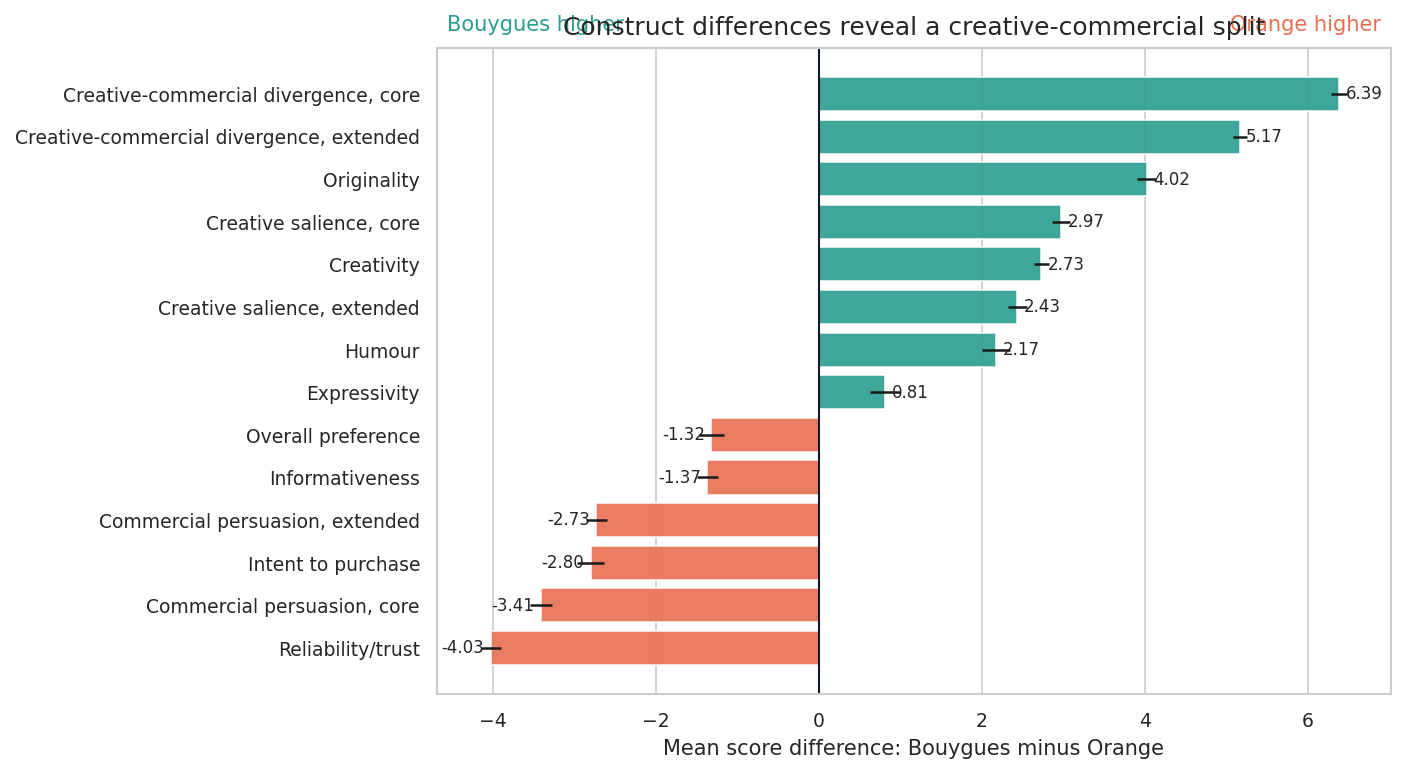

In [9]:
plot_df = distribution.copy()
plot_df = plot_df[plot_df["metric"].str.endswith("_diff")].copy()
plot_df["label"] = plot_df["metric"].map(nice_metric)
plot_df["se"] = plot_df["sd"] / np.sqrt(plot_df["n"])
plot_df["ci95"] = 1.96 * plot_df["se"]
plot_df = plot_df.sort_values("mean")

fig, ax = plt.subplots(figsize=(8.2, 5.6))
colors = np.where(plot_df["mean"] >= 0, BOUYGUES_COLOR, ORANGE_COLOR)
ax.barh(plot_df["label"], plot_df["mean"], xerr=plot_df["ci95"], color=colors, alpha=0.9)
ax.axvline(0, color="#111827", linewidth=1.0)
ax.set_xlabel("Mean score difference: Bouygues minus Orange")
ax.set_ylabel("")
ax.set_title("Construct differences reveal a creative-commercial split")
ax.text(0.01, 1.02, "Bouygues higher", transform=ax.transAxes, ha="left", va="bottom", color=BOUYGUES_COLOR)
ax.text(0.99, 1.02, "Orange higher", transform=ax.transAxes, ha="right", va="bottom", color=ORANGE_COLOR)
for y_pos, value in enumerate(plot_df["mean"]):
    ha = "left" if value >= 0 else "right"
    offset = 0.08 if value >= 0 else -0.08
    ax.text(value + offset, y_pos, f"{value:.2f}", va="center", ha=ha, fontsize=8)
ax.grid(axis="y", visible=False)
save_figure(fig, "fig_01_construct_differences")
plt.show()


## Figure 1b: Signed score distributions

Means can hide heterogeneity. This distributional view shows whether the construct split is broad across respondents or driven by a small number of extreme cases.


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_01b_signed_difference_distributions.png
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_01b_signed_difference_distributions.pdf


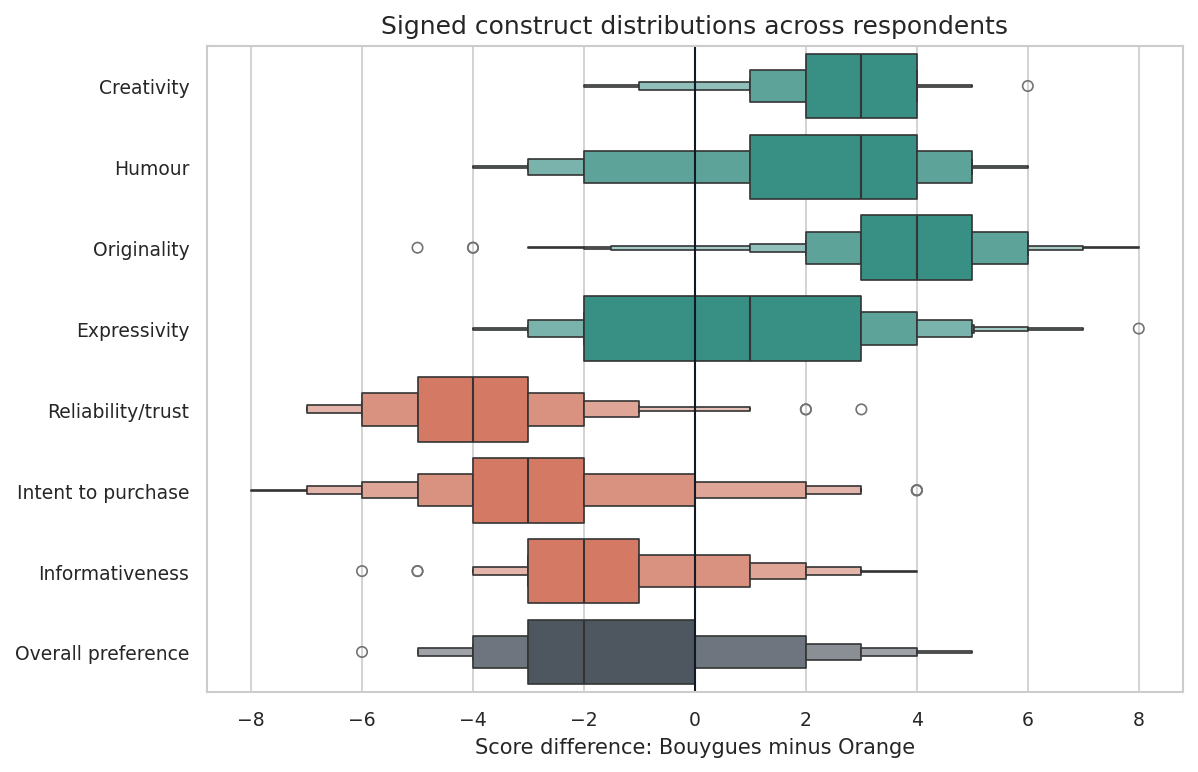

In [10]:
signed_cols = [
    "creativity_diff",
    "humour_diff",
    "originality_diff",
    "expressivity_diff",
    "reliability_trust_diff",
    "intent_to_purchase_diff",
    "informativeness_diff",
    "overall_diff",
]
signed_cols = [col for col in signed_cols if col in metrics.columns]
long_signed = metrics[signed_cols].melt(var_name="metric", value_name="difference").dropna()
long_signed["label"] = long_signed["metric"].map(nice_metric)
order = [nice_metric(col) for col in signed_cols]
family_palette = {
    "Creativity": BOUYGUES_COLOR,
    "Humour": BOUYGUES_COLOR,
    "Originality": BOUYGUES_COLOR,
    "Expressivity": BOUYGUES_COLOR,
    "Reliability/trust": ORANGE_COLOR,
    "Intent to purchase": ORANGE_COLOR,
    "Informativeness": ORANGE_COLOR,
    "Overall preference": NEUTRAL,
}

fig, ax = plt.subplots(figsize=(8.4, 5.6))
sns.boxenplot(
    data=long_signed,
    y="label",
    x="difference",
    order=order,
    palette=family_palette,
    linewidth=0.8,
    k_depth="trustworthy",
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1.0)
ax.set_xlabel("Score difference: Bouygues minus Orange")
ax.set_ylabel("")
ax.set_title("Signed construct distributions across respondents")
save_figure(fig, "fig_01b_signed_difference_distributions")
plt.show()


## Figure 2: Creative-commercial geometry

Each respondent becomes a point in a two-dimensional representation: creative salience difference on the x-axis and commercial persuasion difference on the y-axis. This shows whether the brands separate along a coherent geometry instead of only a black-box prediction.


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_02_creative_commercial_geometry.png
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_02_creative_commercial_geometry.pdf


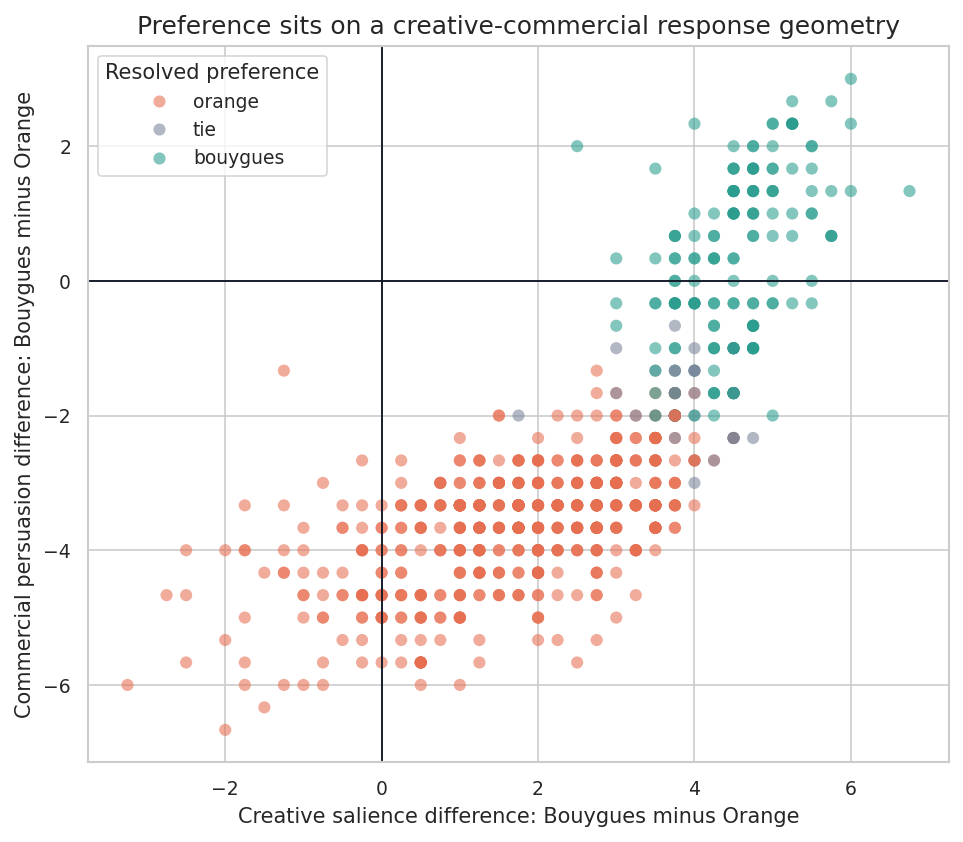

In [11]:
x_col = "creative_salience_extended_diff" if "creative_salience_extended_diff" in metrics.columns else "creative_salience_core_diff"
y_col = "commercial_persuasion_extended_diff" if "commercial_persuasion_extended_diff" in metrics.columns else "commercial_persuasion_core_diff"
geom = metrics.dropna(subset=[x_col, y_col, "resolved_preference"]).copy()
pref_order = [p for p in ["orange", "tie", "bouygues"] if p in set(geom["resolved_preference"])]
palette = {"bouygues": BOUYGUES_COLOR, "orange": ORANGE_COLOR, "tie": TIE_COLOR}

fig, ax = plt.subplots(figsize=(7.4, 6.2))
sns.scatterplot(
    data=geom,
    x=x_col,
    y=y_col,
    hue="resolved_preference",
    hue_order=pref_order,
    palette=palette,
    s=34,
    alpha=0.58,
    edgecolor="none",
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=0.9)
ax.axhline(0, color="#111827", linewidth=0.9)
ax.set_xlabel("Creative salience difference: Bouygues minus Orange")
ax.set_ylabel("Commercial persuasion difference: Bouygues minus Orange")
ax.set_title("Preference sits on a creative-commercial response geometry")
ax.legend(title="Resolved preference", frameon=True)
save_figure(fig, "fig_02_creative_commercial_geometry")
plt.show()


## Figure 3: Divergence by resolved preference

The divergence metric asks whether creative salience exceeds commercial persuasion differently across preferences. This helps separate "liked because memorable/creative" from "chosen because persuasive/reliable".


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_03_divergence_by_preference.png
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_03_divergence_by_preference.pdf


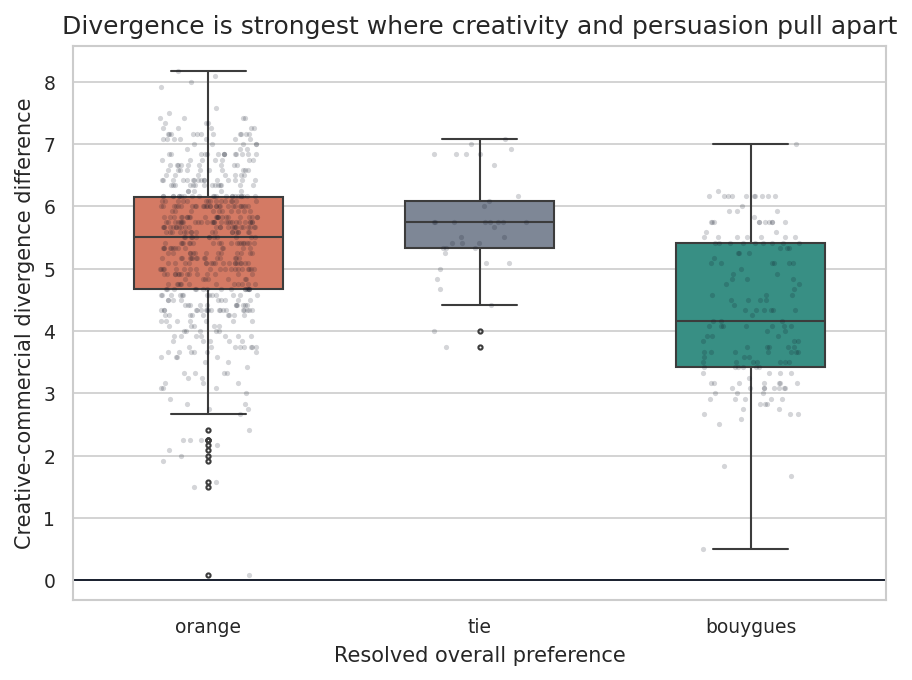

In [12]:
div_col = "creative_commercial_divergence_extended_diff" if "creative_commercial_divergence_extended_diff" in metrics.columns else "creative_commercial_divergence_core_diff"
div_df = metrics.dropna(subset=[div_col, "resolved_preference"]).copy()
order = [p for p in ["orange", "tie", "bouygues"] if p in set(div_df["resolved_preference"])]

fig, ax = plt.subplots(figsize=(7.0, 4.8))
sns.boxplot(
    data=div_df,
    x="resolved_preference",
    y=div_col,
    order=order,
    palette=palette,
    width=0.55,
    fliersize=2,
    ax=ax,
)
sns.stripplot(
    data=div_df,
    x="resolved_preference",
    y=div_col,
    order=order,
    color="#111827",
    alpha=0.18,
    size=2.5,
    jitter=0.18,
    ax=ax,
)
ax.axhline(0, color="#111827", linewidth=0.9)
ax.set_xlabel("Resolved overall preference")
ax.set_ylabel("Creative-commercial divergence difference")
ax.set_title("Divergence is strongest where creativity and persuasion pull apart")
save_figure(fig, "fig_03_divergence_by_preference")
plt.show()


## Figure 4: Construct validity screen

This is an internal validity screen: which construct differences align most strongly with the overall preference difference? It is useful, but it should not be overread as external validation because the construct scores and the overall score can share annotation logic.


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_04_construct_validity.png
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_04_construct_validity.pdf


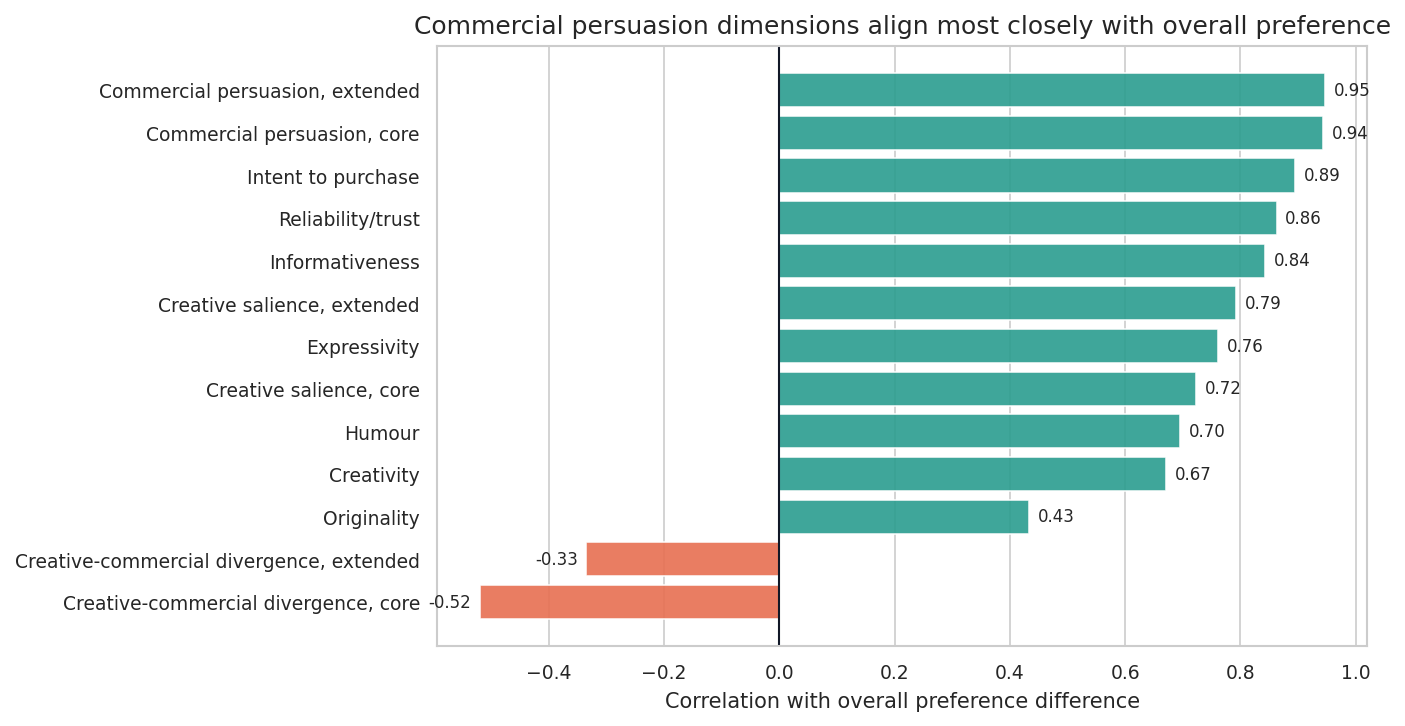

saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_construct_validity.csv
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_construct_validity.tex


,metric,construct_family,n,corr_with_overall_diff,mean_by_bouygues_pref,mean_by_orange_pref
0,"Commercial persuasion, extended",commercial_persuasion,800,0.947,0.187,-3.617
1,"Commercial persuasion, core",commercial_persuasion,800,0.944,-0.405,-4.327
2,Intent to purchase,commercial_persuasion,800,0.895,0.793,-3.842
3,Reliability/trust,commercial_persuasion,800,0.863,-1.604,-4.813
4,Informativeness,commercial_persuasion,800,0.843,1.373,-2.195
5,"Creative salience, extended",creative_salience,800,0.792,4.497,1.760
6,Expressivity,creative_salience,800,0.761,4.089,-0.253
7,"Creative salience, core",creative_salience,800,0.723,4.633,2.430
8,Humour,creative_salience,800,0.695,4.580,1.396
9,Creativity,creative_salience,800,0.671,4.012,2.295


In [13]:
validity_view = validity.copy()
validity_view["label"] = validity_view["metric"].map(nice_metric)
validity_view["abs_corr"] = validity_view["corr_with_overall_diff"].abs()
validity_view = validity_view.sort_values("corr_with_overall_diff")

fig, ax = plt.subplots(figsize=(8.0, 5.2))
bar_colors = np.where(validity_view["corr_with_overall_diff"] >= 0, BOUYGUES_COLOR, ORANGE_COLOR)
ax.barh(validity_view["label"], validity_view["corr_with_overall_diff"], color=bar_colors, alpha=0.9)
ax.axvline(0, color="#111827", linewidth=1.0)
ax.set_xlabel("Correlation with overall preference difference")
ax.set_ylabel("")
ax.set_title("Commercial persuasion dimensions align most closely with overall preference")
for y_pos, value in enumerate(validity_view["corr_with_overall_diff"]):
    ha = "left" if value >= 0 else "right"
    offset = 0.015 if value >= 0 else -0.015
    ax.text(value + offset, y_pos, f"{value:.2f}", va="center", ha=ha, fontsize=8)
ax.grid(axis="y", visible=False)
save_figure(fig, "fig_04_construct_validity")
plt.show()

validity_table = validity.sort_values("corr_with_overall_diff", key=lambda s: s.abs(), ascending=False).copy()
validity_table["metric"] = validity_table["metric"].map(nice_metric)
validity_table = validity_table[
    [
        "metric",
        "construct_family",
        "n",
        "corr_with_overall_diff",
        "mean_by_bouygues_pref",
        "mean_by_orange_pref",
    ]
].round(3)
export_table(validity_table, "paper_table_construct_validity")
display(validity_table)


## Figure 5: Preference reconstruction baselines

The preference-reconstruction task asks how well different representations preserve the overall preference label. High scores here mean the construct layer is internally coherent. They do not yet prove out-of-sample human market prediction.


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_05_preference_reconstruction.png
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_05_preference_reconstruction.pdf


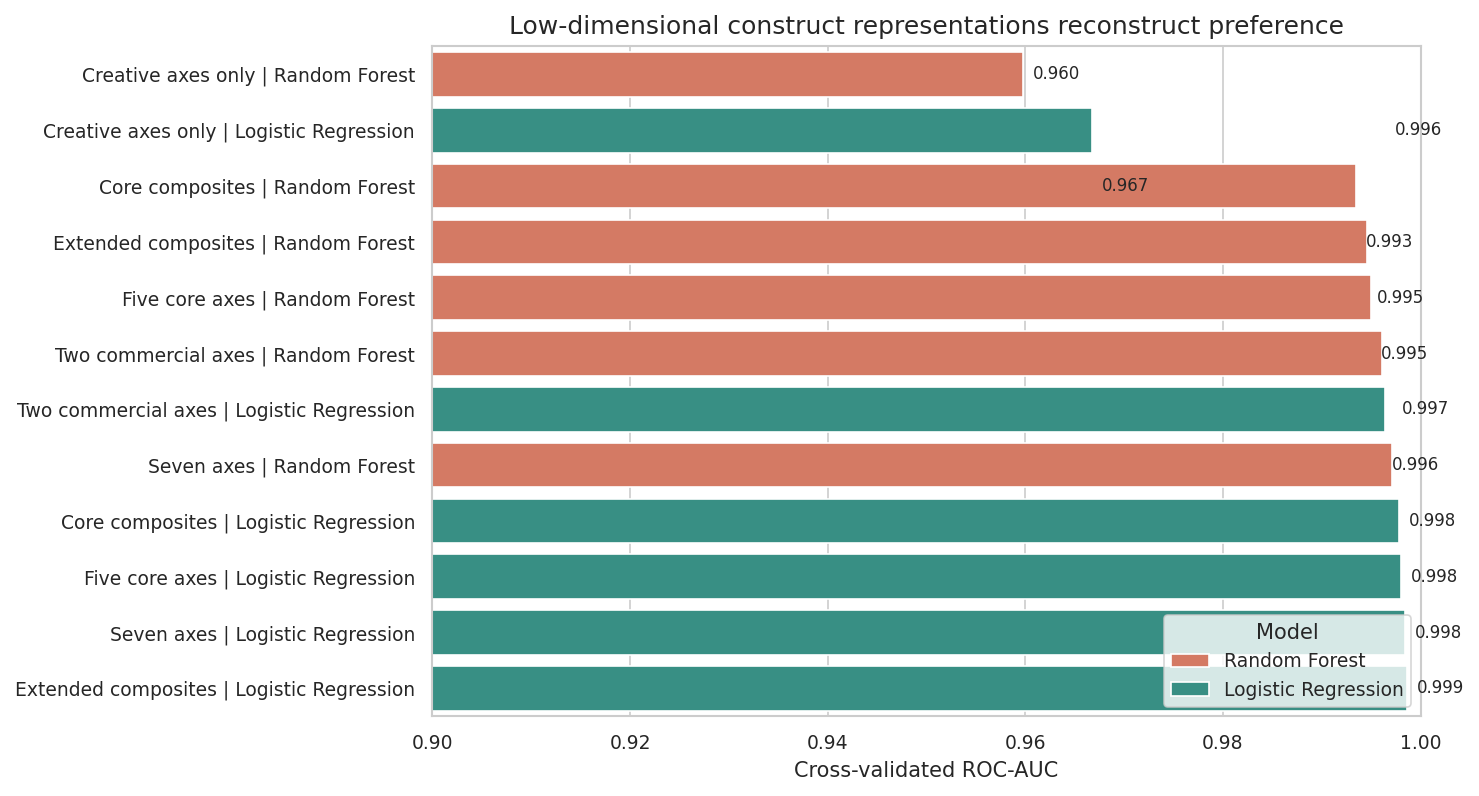

saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_preference_reconstruction.csv
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_preference_reconstruction.tex


,feature_set,model,n,n_features,roc_auc,average_precision,balanced_accuracy,f1_bouygues,features
0,Extended composites,Logistic Regression,763,3,0.999,0.996,0.978,0.941,creative_salience_extended_diff; commercial_pe...
1,Seven axes,Logistic Regression,763,7,0.998,0.995,0.979,0.944,creativity_diff; humour_diff; originality_diff...
2,Five core axes,Logistic Regression,763,5,0.998,0.994,0.968,0.906,creativity_diff; humour_diff; originality_diff...
3,Core composites,Logistic Regression,763,3,0.998,0.993,0.971,0.920,creative_salience_core_diff; commercial_persua...
4,Seven axes,Random Forest,763,7,0.997,0.991,0.961,0.943,creativity_diff; humour_diff; originality_diff...
5,Two commercial axes,Logistic Regression,763,2,0.996,0.988,0.971,0.913,intent_to_purchase_diff; reliability_trust_diff
6,Two commercial axes,Random Forest,763,2,0.996,0.987,0.961,0.930,intent_to_purchase_diff; reliability_trust_diff
7,Five core axes,Random Forest,763,5,0.995,0.980,0.955,0.932,creativity_diff; humour_diff; originality_diff...
8,Extended composites,Random Forest,763,3,0.995,0.988,0.965,0.936,creative_salience_extended_diff; commercial_pe...
9,Core composites,Random Forest,763,3,0.993,0.980,0.965,0.931,creative_salience_core_diff; commercial_persua...


In [14]:
model_plot = model_summary.copy()
model_plot["feature_set_label"] = model_plot["feature_set"].map(FEATURE_SET_LABELS).fillna(model_plot["feature_set"])
model_plot["model_label"] = model_plot["model"].str.replace("_", " ").str.title()
model_plot["label"] = model_plot["feature_set_label"] + " | " + model_plot["model_label"]
model_plot = model_plot.sort_values("roc_auc", ascending=True)

fig, ax = plt.subplots(figsize=(8.5, 5.8))
sns.barplot(
    data=model_plot,
    y="label",
    x="roc_auc",
    hue="model_label",
    dodge=False,
    palette={"Logistic Regression": BOUYGUES_COLOR, "Random Forest": ORANGE_COLOR},
    ax=ax,
)
ax.axvline(0.5, color="#111827", linewidth=0.8, linestyle=":")
ax.set_xlim(0.9, 1.0)
ax.set_xlabel("Cross-validated ROC-AUC")
ax.set_ylabel("")
ax.set_title("Low-dimensional construct representations reconstruct preference")
ax.legend(title="Model", frameon=True, loc="lower right")
for patch, value in zip(ax.patches, model_plot["roc_auc"]):
    ax.text(value + 0.001, patch.get_y() + patch.get_height() / 2, f"{value:.3f}", va="center", fontsize=8)
save_figure(fig, "fig_05_preference_reconstruction")
plt.show()

model_table = model_summary.copy()
model_table["feature_set"] = model_table["feature_set"].map(FEATURE_SET_LABELS).fillna(model_table["feature_set"])
model_table["model"] = model_table["model"].str.replace("_", " ").str.title()
model_table = model_table[
    ["feature_set", "model", "n", "n_features", "roc_auc", "average_precision", "balanced_accuracy", "f1_bouygues", "features"]
].round(3)
export_table(model_table, "paper_table_preference_reconstruction")
display(model_table)


## Leakage and circularity audit

Very high reconstruction scores are not automatically evidence of external predictive validity. This audit makes the main risks visible and turns them into next-step experiments.


In [15]:
high_corr = validity.assign(abs_corr=lambda d: d["corr_with_overall_diff"].abs())
high_corr_metrics = ", ".join(high_corr.loc[high_corr["abs_corr"] >= 0.90, "metric"].map(nice_metric).tolist())
if not high_corr_metrics:
    high_corr_metrics = "none above threshold"

target_proximate_features = [
    col
    for col in [
        "intent_to_purchase_diff",
        "commercial_persuasion_core_diff",
        "commercial_persuasion_extended_diff",
    ]
    if col in metrics.columns
]

audit = pd.DataFrame(
    [
        {
            "risk": "Shared annotation logic",
            "mechanism": "Construct scores and overall scores can be generated from the same interview material and model pass.",
            "diagnostic": f"Construct correlations >= 0.90: {high_corr_metrics}.",
            "expected_action": "Validate on human-coded scores or a separately annotated overall label.",
            "status": "open",
        },
        {
            "risk": "Target-proximate predictors",
            "mechanism": "Intent-to-purchase and commercial persuasion are conceptually close to overall preference.",
            "diagnostic": "Target-proximate columns present: " + ", ".join(target_proximate_features),
            "expected_action": "Report creative-only and no-intent/no-commercial sensitivity models.",
            "status": "partly addressed by feature-set comparison",
        },
        {
            "risk": "Single-campaign overfit",
            "mechanism": "Results may reflect this Bouygues/Orange contrast rather than a general metric property.",
            "diagnostic": "Only one campaign pair is represented in the current output contract.",
            "expected_action": "Repeat across more campaigns and brands; treat this as a case study for now.",
            "status": "open",
        },
        {
            "risk": "Question wording concentration",
            "mechanism": "Some comparison questions may dominate the scored signal.",
            "diagnostic": "Use question_signal_table to inspect whether signal is concentrated in a few prompts.",
            "expected_action": "Run ablations by question family and compare against embeddings.",
            "status": "open",
        },
        {
            "risk": "Model-as-evaluator circularity",
            "mechanism": "A model can appear accurate by reproducing scoring rules already embedded in the labels.",
            "diagnostic": "Near-perfect AUC is interpreted as internal coherence, not external market prediction.",
            "expected_action": "Add external labels, repeated annotation models, calibration curves, and uncertainty intervals.",
            "status": "open",
        },
    ]
)
export_table(audit, "paper_table_leakage_circularity_audit", latex=False)
display(audit)


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_leakage_circularity_audit.csv


,risk,mechanism,diagnostic,expected_action,status
0,Shared annotation logic,Construct scores and overall scores can be gen...,Construct correlations >= 0.90: Commercial per...,Validate on human-coded scores or a separately...,open
1,Target-proximate predictors,Intent-to-purchase and commercial persuasion a...,Target-proximate columns present: intent_to_pu...,Report creative-only and no-intent/no-commerci...,partly addressed by feature-set comparison
2,Single-campaign overfit,Results may reflect this Bouygues/Orange contr...,Only one campaign pair is represented in the c...,Repeat across more campaigns and brands; treat...,open
3,Question wording concentration,Some comparison questions may dominate the sco...,Use question_signal_table to inspect whether s...,Run ablations by question family and compare a...,open
4,Model-as-evaluator circularity,A model can appear accurate by reproducing sco...,Near-perfect AUC is interpreted as internal co...,"Add external labels, repeated annotation model...",open


## Figure 6: Random-forest motivation

The earlier random-forest notebook is useful as a motivation because its explanation artifacts show which dimensions carried the original preference reconstruction. The next step is not simply "train a bigger forest"; it is to formalize why these dimensions work and whether they remain stable across representations.


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_06_rf_motivation_shap_importance.png
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_06_rf_motivation_shap_importance.pdf


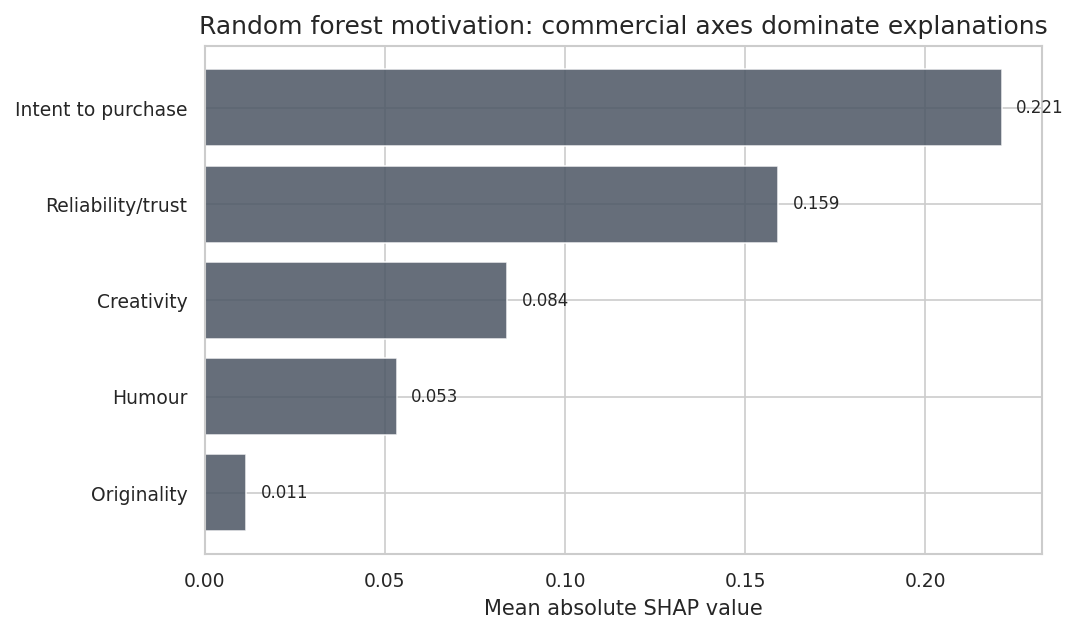

saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_rf_motivation.csv
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_rf_motivation.tex


,feature,rf_impurity,perm_importance,mean_abs_shap
0,Intent to purchase,0.420,0.104,0.221
1,Reliability/trust,0.334,0.023,0.159
2,Creativity,0.120,0.001,0.084
3,Humour,0.108,-0.001,0.053
4,Originality,0.018,-0.000,0.011


In [16]:
rf_feature_path = RF_OUTPUT_DIR / "feature_importance.csv"
if rf_feature_path.exists():
    rf_importance = pd.read_csv(rf_feature_path)
    rf_importance["label"] = rf_importance["feature"].map(nice_metric)
    rf_importance = rf_importance.sort_values("mean_abs_shap", ascending=True)

    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    ax.barh(rf_importance["label"], rf_importance["mean_abs_shap"], color=NEUTRAL, alpha=0.85)
    ax.set_xlabel("Mean absolute SHAP value")
    ax.set_ylabel("")
    ax.set_title("Random forest motivation: commercial axes dominate explanations")
    for y_pos, value in enumerate(rf_importance["mean_abs_shap"]):
        ax.text(value + 0.004, y_pos, f"{value:.3f}", va="center", fontsize=8)
    save_figure(fig, "fig_06_rf_motivation_shap_importance")
    plt.show()

    rf_table = rf_importance[["feature", "rf_impurity", "perm_importance", "mean_abs_shap"]].copy()
    rf_table["feature"] = rf_table["feature"].map(nice_metric)
    rf_table = rf_table.sort_values("mean_abs_shap", ascending=False).round(3)
    export_table(rf_table, "paper_table_rf_motivation")
    display(rf_table)
else:
    display(Markdown("Random-forest feature importance file not found. Skipping this optional motivation figure."))


## Figure 7: Question-level signal map

This table/heatmap asks a different question: which interview questions actually carry the preference-relevant signals? This is close to the supervisor's "dimensions sorted per signal" idea: dimensions can be sorted by their signal strength, or questions can be transposed into a dimension-by-question map.


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_07_question_dimension_signal_heatmap.png
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_07_question_dimension_signal_heatmap.pdf


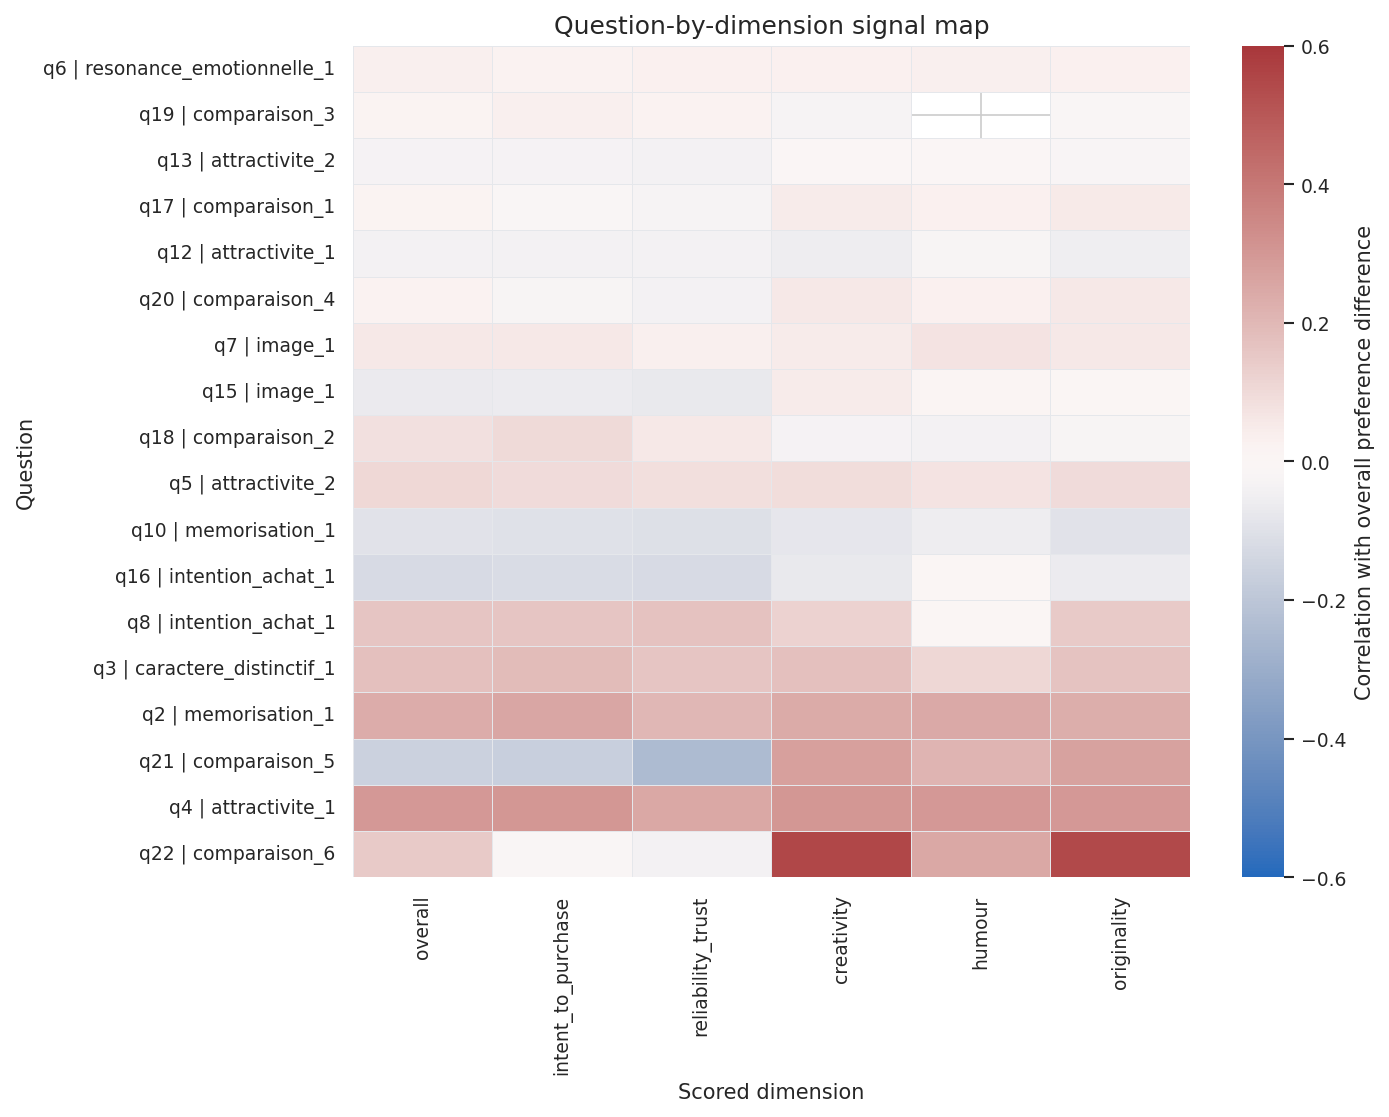

saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_top_question_signals.csv
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_top_question_signals.tex


,question_id,question_column,question_family,question_brand_block,dimension,n,mean_question_diff,corr_with_overall_diff,signal_strength_abs_corr
0,q22,Q_comparaison_6,comparaison_6,comparison,Creativity,800,1.066,0.553,0.553
1,q22,Q_comparaison_6,comparaison_6,comparison,Originality,800,0.336,0.547,0.547
2,q4,Q_bouygues_attractivite_1,attractivite_1,bouygues_specific,Intent To Purchase,800,0.596,0.303,0.303
3,q4,Q_bouygues_attractivite_1,attractivite_1,bouygues_specific,Creativity,800,0.904,0.302,0.302
4,q4,Q_bouygues_attractivite_1,attractivite_1,bouygues_specific,Originality,800,0.838,0.299,0.299
5,q4,Q_bouygues_attractivite_1,attractivite_1,bouygues_specific,Overall,800,0.778,0.297,0.297
6,q4,Q_bouygues_attractivite_1,attractivite_1,bouygues_specific,Humour,800,0.778,0.297,0.297
7,q21,Q_comparaison_5,comparaison_5,comparison,Creativity,800,0.620,0.273,0.273
8,q21,Q_comparaison_5,comparaison_5,comparison,Originality,800,0.559,0.270,0.270
9,q2,Q_bouygues_memorisation_1,memorisation_1,bouygues_specific,Intent To Purchase,800,0.832,0.255,0.255


In [17]:
q = qsignals.copy()
q["row_label"] = q["question_id"].astype(str) + " | " + q["question_family"].astype(str)
top_question_keys = (
    q.groupby(["question_id", "question_family"])["signal_strength_abs_corr"]
    .max()
    .sort_values(ascending=False)
    .head(18)
    .index
)
mask = q.set_index(["question_id", "question_family"]).index.isin(top_question_keys)
q_top = q.loc[mask].copy()

row_order = (
    q_top.groupby("row_label")["signal_strength_abs_corr"]
    .max()
    .sort_values(ascending=True)
    .index
)
heat = q_top.pivot_table(
    index="row_label",
    columns="dimension",
    values="corr_with_overall_diff",
    aggfunc="mean",
)
heat = heat.reindex(row_order)
dimension_order = [d for d in ["overall", "intent_to_purchase", "reliability_trust", "informativeness", "creativity", "humour", "originality", "expressivity"] if d in heat.columns]
heat = heat[dimension_order]

fig, ax = plt.subplots(figsize=(9.0, 7.2))
sns.heatmap(
    heat,
    cmap="vlag",
    center=0,
    vmin=-0.6,
    vmax=0.6,
    linewidths=0.4,
    linecolor="#e5e7eb",
    cbar_kws={"label": "Correlation with overall preference difference"},
    ax=ax,
)
ax.set_xlabel("Scored dimension")
ax.set_ylabel("Question")
ax.set_title("Question-by-dimension signal map")
save_figure(fig, "fig_07_question_dimension_signal_heatmap")
plt.show()

top_signals = qsignals.head(25).copy()
top_signals["dimension"] = top_signals["dimension"].str.replace("_", " ").str.title()
top_signals = top_signals[
    [
        "question_id",
        "question_column",
        "question_family",
        "question_brand_block",
        "dimension",
        "n",
        "mean_question_diff",
        "corr_with_overall_diff",
        "signal_strength_abs_corr",
    ]
].round(3)
export_table(top_signals, "paper_table_top_question_signals")
display(top_signals)


## Figure 8: Construct correlation matrix

This diagnostic checks whether the representation is low-dimensional. Strong blocks suggest redundancy or latent factors; weak blocks suggest genuinely distinct dimensions. This is a natural bridge toward embeddings, factor models, contrastive representations, or metric learning.


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_08_construct_correlation_matrix.png
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_figures/fig_08_construct_correlation_matrix.pdf


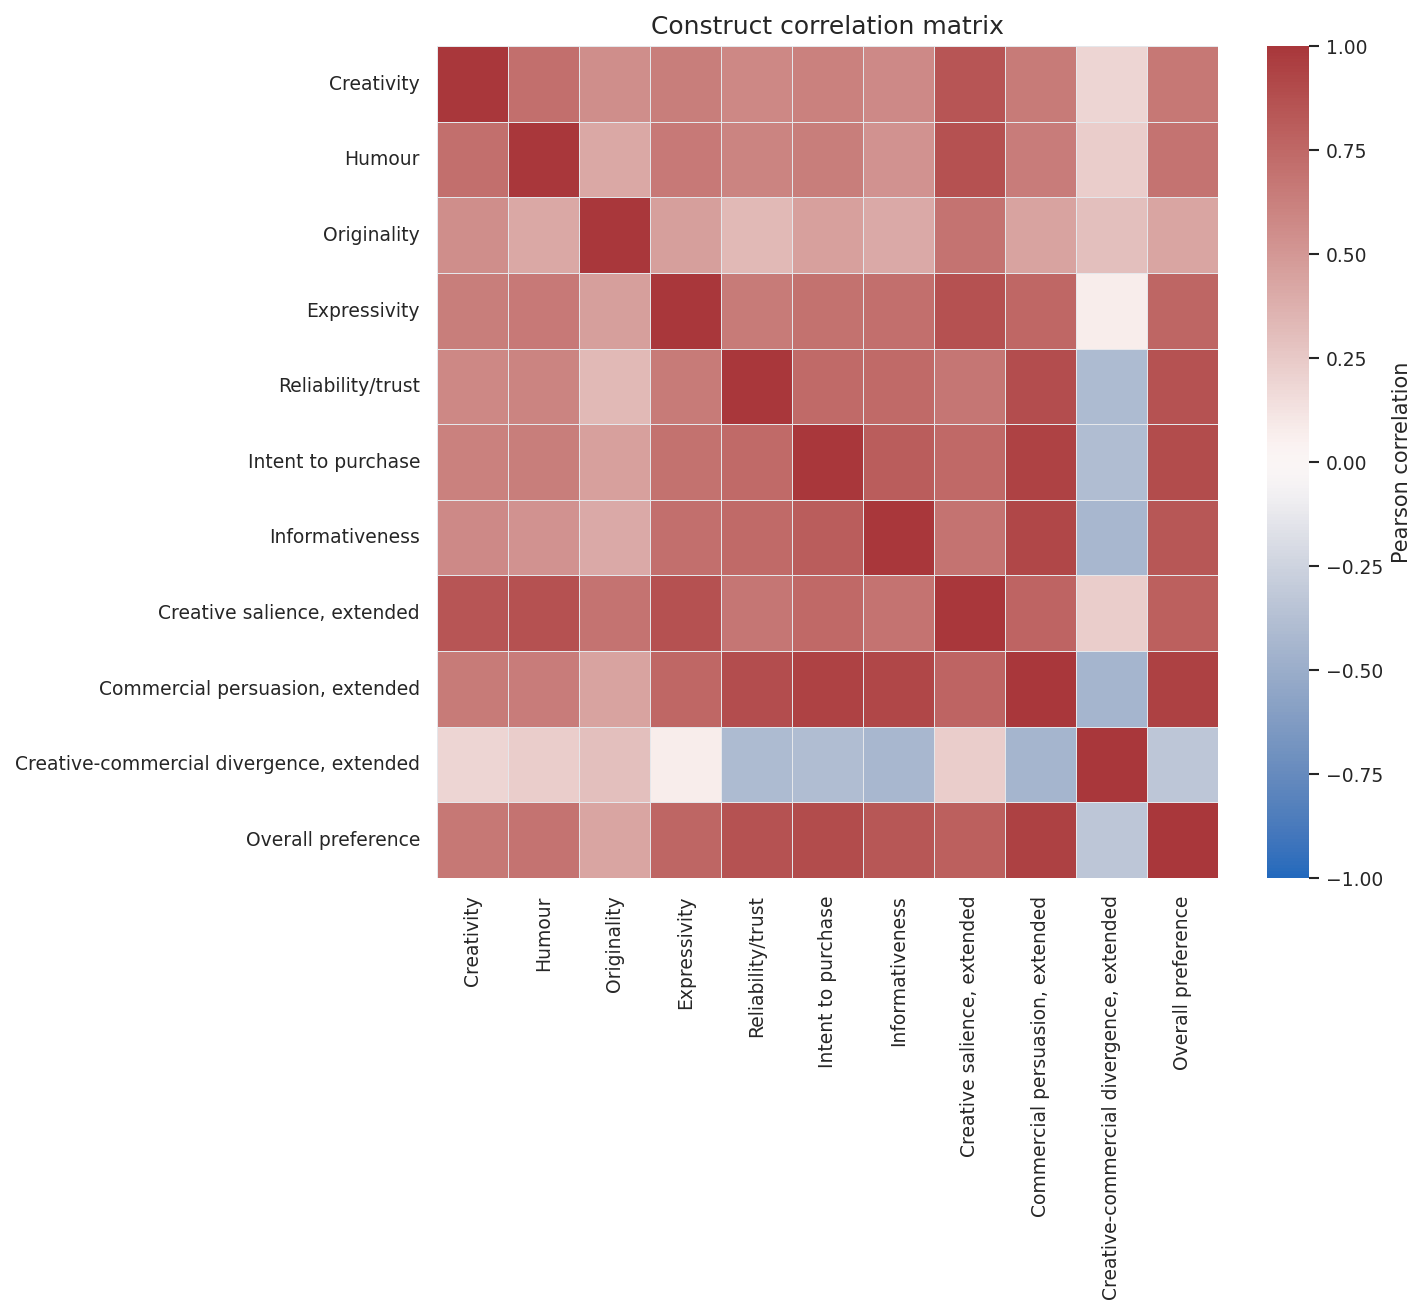

In [18]:
candidate_cols = [
    "creativity_diff",
    "humour_diff",
    "originality_diff",
    "expressivity_diff",
    "reliability_trust_diff",
    "intent_to_purchase_diff",
    "informativeness_diff",
    "creative_salience_extended_diff",
    "commercial_persuasion_extended_diff",
    "creative_commercial_divergence_extended_diff",
    "overall_diff",
]
available_cols = [col for col in candidate_cols if col in metrics.columns]
corr = metrics[available_cols].corr()
corr = corr.rename(index=nice_metric, columns=nice_metric)

fig, ax = plt.subplots(figsize=(8.4, 7.2))
sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    linecolor="#e5e7eb",
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set_title("Construct correlation matrix")
save_figure(fig, "fig_08_construct_correlation_matrix")
plt.show()


## Robustness screen

This is a starter robustness table. It checks whether the two core construct differences are stable across observed respondent groups. It is descriptive; it should become a more formal robustness section if the paper develops.


In [19]:
robust_rows = []

if "age" in metrics.columns:
    tmp = metrics.copy()
    tmp["age_band"] = pd.cut(
        pd.to_numeric(tmp["age"], errors="coerce"),
        bins=[0, 24, 34, 44, 54, 64, 120],
        labels=["<=24", "25-34", "35-44", "45-54", "55-64", "65+"],
    )
    for group_value, g in tmp.groupby("age_band", observed=True):
        if len(g) >= 20:
            robust_rows.append(
                {
                    "group_type": "age_band",
                    "group": str(group_value),
                    "n": len(g),
                    "creative_salience_diff_mean": g[x_col].mean(),
                    "commercial_persuasion_diff_mean": g[y_col].mean(),
                    "overall_diff_mean": g["overall_diff"].mean(),
                    "bouygues_pref_pct": (g["resolved_preference"] == "bouygues").mean() * 100,
                }
            )

if "gender" in metrics.columns:
    for group_value, g in metrics.groupby("gender"):
        if len(g) >= 20:
            robust_rows.append(
                {
                    "group_type": "gender",
                    "group": str(group_value),
                    "n": len(g),
                    "creative_salience_diff_mean": g[x_col].mean(),
                    "commercial_persuasion_diff_mean": g[y_col].mean(),
                    "overall_diff_mean": g["overall_diff"].mean(),
                    "bouygues_pref_pct": (g["resolved_preference"] == "bouygues").mean() * 100,
                }
            )

robustness = pd.DataFrame(robust_rows)
if not robustness.empty:
    robustness_rounded = robustness.round(3)
    export_table(robustness_rounded, "paper_table_group_robustness")
    display(robustness_rounded)
else:
    display(Markdown("No robustness groups were available with sufficient sample size."))


saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_group_robustness.csv
saved /Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/paper_tables/paper_table_group_robustness.tex


,group_type,group,n,creative_salience_diff_mean,commercial_persuasion_diff_mean,overall_diff_mean,bouygues_pref_pct
0,age_band,<=24,109,3.477,-1.239,0.459,50.459
1,age_band,25-34,140,3.645,-1.374,0.386,45.714
2,age_band,35-44,69,3.344,-2.198,-0.464,30.435
3,age_band,45-54,150,2.688,-2.813,-1.353,13.333
4,age_band,55-64,113,1.814,-3.569,-2.354,3.540
5,age_band,65+,219,1.001,-4.020,-3.009,2.283
6,gender,Female,310,2.428,-2.584,-1.155,23.871
7,gender,Male,429,2.247,-3.031,-1.690,15.152
8,gender,Non-binary,61,3.787,-1.366,0.443,49.180


## Supervisor-facing interpretation

This notebook supports a second, more technical paper direction:

1. The empirical phenomenon is a stable creative-commercial split: one brand is stronger on creative salience, while the other is stronger on commercial persuasion.
2. The ML object is a representation problem: can lower-level response constructs, question signals, and embeddings preserve the same preference geometry?
3. The first baseline is deliberately simple: logistic regression and random forests reconstruct preference from construct differences.
4. The important next step is not just higher accuracy. It is stronger validation: human calibration, alternative annotation models, embedding representations, sensitivity to metric weights, and robustness across panels/campaigns.

Defensible near-term claim: AirPanel can be formalized as a metric-learning/evaluation problem in which synthetic interviews are transformed into structured construct representations whose geometry explains preference-like judgments.

Claim to avoid for now: these metrics prove real market lift or replace human studies.


In [20]:
creative_row = distribution.loc[distribution["metric"].eq(x_col)].iloc[0]
commercial_row = distribution.loc[distribution["metric"].eq(y_col)].iloc[0]
div_row = distribution.loc[distribution["metric"].eq(div_col)].iloc[0]
best_model = model_summary.sort_values("roc_auc", ascending=False).iloc[0]
top_question = qsignals.iloc[0]

summary_md = f'''
### Computed headline results

- Creative salience difference (`{nice_metric(x_col)}`): mean = {creative_row['mean']:.2f}, with {creative_row['pct_bouygues_positive']:.1f}% of respondents scoring Bouygues higher.
- Commercial persuasion difference (`{nice_metric(y_col)}`): mean = {commercial_row['mean']:.2f}, with {commercial_row['pct_orange_negative']:.1f}% of respondents scoring Orange higher.
- Creative-commercial divergence (`{nice_metric(div_col)}`): mean = {div_row['mean']:.2f}.
- Best internal preference-reconstruction baseline: {FEATURE_SET_LABELS.get(best_model['feature_set'], best_model['feature_set'])} using {best_model['model'].replace('_', ' ')}, ROC-AUC = {best_model['roc_auc']:.3f}.
- Strongest question-level signal: {top_question['question_id']} / {top_question['question_column']} on {top_question['dimension']}, correlation with overall difference = {top_question['corr_with_overall_diff']:.3f}.

These values are useful as notebook-level evidence for the research direction, not as final publication claims without external validation.
'''
display(Markdown(summary_md))



### Computed headline results

- Creative salience difference (`Creative salience, extended`): mean = 2.43, with 90.6% of respondents scoring Bouygues higher.
- Commercial persuasion difference (`Commercial persuasion, extended`): mean = -2.73, with 88.5% of respondents scoring Orange higher.
- Creative-commercial divergence (`Creative-commercial divergence, extended`): mean = 5.17.
- Best internal preference-reconstruction baseline: Extended composites using logistic regression, ROC-AUC = 0.999.
- Strongest question-level signal: q22 / Q_comparaison_6 on creativity, correlation with overall difference = 0.553.

These values are useful as notebook-level evidence for the research direction, not as final publication claims without external validation.


In [21]:
created = sorted([p.name for p in FIG_DIR.glob("*.png")]) + sorted([p.name for p in TABLE_DIR.glob("*.csv")])
display(pd.DataFrame({"created_artifact": created}))


,created_artifact
0,fig_00_metric_ladder_overview.png
1,fig_01_construct_differences.png
2,fig_01b_signed_difference_distributions.png
3,fig_02_creative_commercial_geometry.png
4,fig_03_divergence_by_preference.png
5,fig_04_construct_validity.png
6,fig_05_preference_reconstruction.png
7,fig_06_rf_motivation_shap_importance.png
8,fig_07_question_dimension_signal_heatmap.png
9,fig_08_construct_correlation_matrix.png
